# CA Experiment 3: QPM vs. CMG-CDK Ablation

**Runtime:** Colab Pro **L4 GPU** (or A100) for Battery C (Qwen2.5-7B inference).  
Batteries A, B, and Variance Calibration require **no GPU**.

**Before running Battery C:** Runtime → Change runtime type → **L4 GPU** (or A100).

**This notebook covers** the full Experiment 3 pipeline:
- **H4 Variance Calibration** — SNR check (must PASS before running main batteries)
- **Battery A (H1)** — Order effects: 30 sequence pairs × 2 orderings × QPM vs. CMG-CDK → Jensen-Shannon Divergence
- **Battery B (H2)** — Ambivalence: 20 conflict scenarios × QPM vs. CMG-CDK → Shannon entropy
- **Battery C (H3)** — PersonaScore: 30 scripts × QPM vs. CMG-CDK × 8 probe turns → Sonnet 4.5 judge
- **Analysis** — Paired t-test, Cohen's d, decision rule outcome

All outputs are saved to Google Drive and the notebook is **resumable** — re-running a cell skips already-completed work.

## Cell 1: Mount Google Drive & Set API Key

Upload the `CA_Experiment_3` folder (containing this notebook and all `.py` files) to your Google Drive before running.  
Also ensure `CA_Experiment_2/` is on Drive (Battery C imports the LoRA-10K adapter and SCI assets from there).

In [3]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import os

PROJECT_DIR  = '/content/drive/MyDrive/CA_Experiment_3'
EXP2_DIR     = '/content/drive/MyDrive/CA_Experiment_2'
EXP1_DIR     = '/content/drive/MyDrive/CA_Experiment_1'

assert os.path.exists(PROJECT_DIR), (
    f'Upload CA_Experiment_3 to Drive first! Not found at {PROJECT_DIR}'
)
assert os.path.exists(EXP2_DIR), (
    f'CA_Experiment_2 must also be on Drive (needed for LoRA adapter + SCI assets). '
    f'Not found at {EXP2_DIR}'
)

# API key — Colab Secrets preferred, then .env file on Drive
ANTHROPIC_API_KEY = ''
try:
    ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
    print('API key loaded from Colab Secrets')
except Exception:
    pass

if not ANTHROPIC_API_KEY:
    for env_path in [
        os.path.join(PROJECT_DIR, '.env'),
        os.path.join(EXP2_DIR, '.env'),
        os.path.join(EXP1_DIR, '.env'),
    ]:
        if os.path.exists(env_path):
            with open(env_path) as f:
                for line in f:
                    for key_prefix in ('ANTHROPIC_API_KEY=', 'CHA_EXPERIMENT_SONNET_KEY='):
                        if line.startswith(key_prefix):
                            ANTHROPIC_API_KEY = line.strip().split('=', 1)[1]
                            print(f'API key loaded from {env_path}')
                            break
                if ANTHROPIC_API_KEY:
                    break

assert ANTHROPIC_API_KEY, (
    'No API key found. Set ANTHROPIC_API_KEY via Colab Secrets, '
    'or place it in a .env file in CA_Experiment_3/, CA_Experiment_2/, or CA_Experiment_1/.'
)
os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY
os.environ['CHA_EXPERIMENT_SONNET_KEY'] = ANTHROPIC_API_KEY

print(f'Project dir : {PROJECT_DIR}')
print(f'Exp 2 dir   : {EXP2_DIR}')
print(f'API key     : ...{ANTHROPIC_API_KEY[-8:]}')

Mounted at /content/drive
API key loaded from /content/drive/MyDrive/CA_Experiment_2/.env
Project dir : /content/drive/MyDrive/CA_Experiment_3
Exp 2 dir   : /content/drive/MyDrive/CA_Experiment_2
API key     : ...9tYw8wAA


## Cell 2: Install Python Dependencies

In [4]:
# Core deps for Batteries A, B, and Variance Calibration (no GPU needed)
# pylatexenc is needed by Qiskit's matplotlib circuit drawer (Cell 2b)
!pip install -q qiskit qiskit-aer numpy scipy matplotlib pylatexenc vaderSentiment anthropic python-dotenv

import os, sys
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)
# EXP2_DIR is NOT added to sys.path: ca_assets.py loads it via importlib by file
# path to avoid the EXP2_DIR/ca_assets.py shadowing the Exp3 module.

# Smoke-test imports
import ca_assets as A
from qpm import QPM, QUBIT_LABELS, N_TRAIT_QUBITS
from cmg_cdk import CMG_CDK, SIGMA

print(f'Trait qubits       : {N_TRAIT_QUBITS}')
print(f'Qubit labels       : {QUBIT_LABELS}')
print(f'Battery A pairs    : {len(A.BATTERY_A_PAIRS)}')
print(f'Battery B scenarios: {len(A.BATTERY_B_SCENARIOS)}')
print(f'Profiles           : {list(A.PROFILES.keys())}')

# Smoke-test Anthropic API (Battery C judge)
import anthropic
client = anthropic.Anthropic()
resp = client.messages.create(
    model='claude-sonnet-4-5',
    max_tokens=10,
    messages=[{'role': 'user', 'content': 'Say "ok".'}],
)
print(f'API smoke test     : {resp.content[0].text}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 14.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 134.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.0/833.0 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.1 MB/s eta 0:00:00
Trait qubits       : 11
Qubit labels       : ['O_exp', 'O_int', 'O_val', 'C_ind', 'C_ord', 'E_ent', 'E_ass', 'A_com', 'A_pol', 'N_vol', 'N_wth']
Battery A pairs    : 30
Battery B scenarios: 20
Profiles           : ['psychotherapy', 'software_eng']
API smoke test     : ok


## Cell 2b: QPM Circuit Visualization

Renders the full 12-qubit circuit for the psychotherapy profile with a neutral d-vector.  
Annotated layers: **Ry init** → **CNOT intra-domain** → **CRz inter-domain** → **context Ry** → **noise id gates** → **measurement**.

The circuit diagram is the main visual evidence that the QPM implements non-commutative unitary evolution — the gate sequence is the paper's §3 in executable form.

Qubits : 12 (11 trait + 1 ancilla)
Depth  : 14
Gates  : {'ry': 21, 'x': 12, 'id': 12, 'measure': 11, 'crz': 8, 'cx': 5, 'barrier': 4}

Circuit layers:
  Stage 1 — Ry initialization      : 11 Ry gates (one per trait qubit)
  Stage 2 — Intra-domain CNOT       : 5 CX gates  (within-domain correlations)
  Stage 3 — Inter-domain CRz        : 8 CRz gates (cross-domain correlations, X-CRz-X for ρ<0)
  Stage 4 — Context Ry (d-vector)   : 10 Ry gates (non-commutative context layer)
  Stage 5 — Lindblad noise carriers : 12 id gates (noise attached by AerSimulator)
  Stage 6 — Measurement             : 11 measure  (trait qubits only; ancilla q11 traced out)


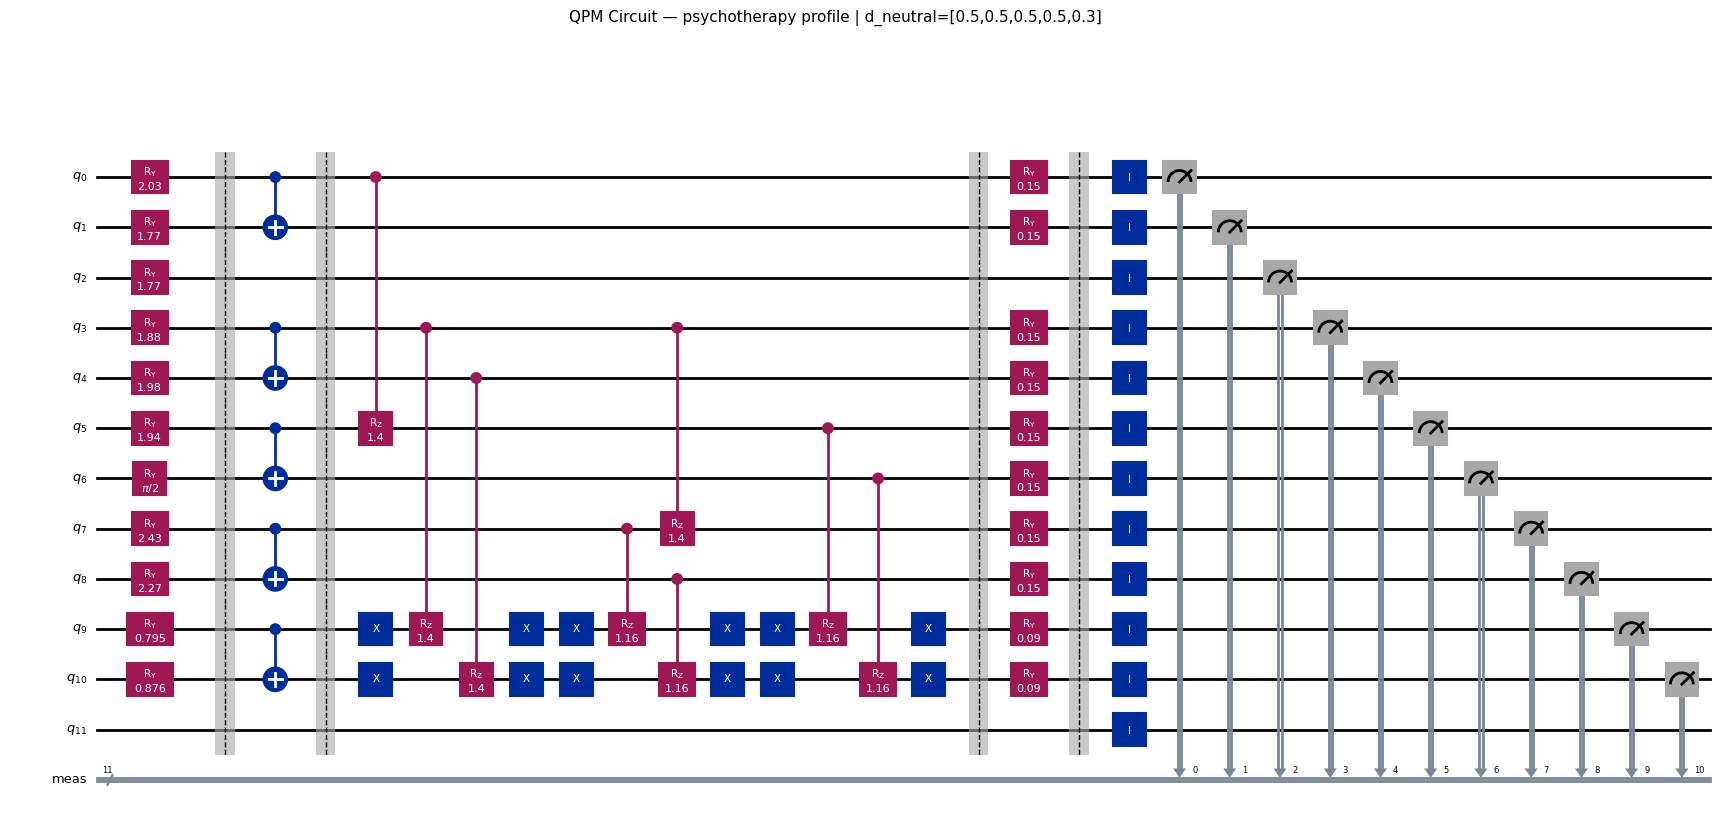

In [3]:
import os, sys
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

import matplotlib.pyplot as plt
from IPython.display import display
from qpm import QPM, QUBIT_LABELS, N_TRAIT_QUBITS, N_TOTAL_QUBITS
import ca_assets as A

profile = A.PROFILES['psychotherapy']
qpm_vis = QPM(profile, n_shots=256)

d_neutral = [0.5, 0.5, 0.5, 0.5, 0.3]
circuit = qpm_vis._build_circuit([d_neutral])

print(f'Qubits : {N_TOTAL_QUBITS} ({N_TRAIT_QUBITS} trait + 1 ancilla)')
print(f'Depth  : {circuit.depth()}')
print(f'Gates  : {dict(circuit.count_ops())}')
print()
print('Circuit layers:')
print('  Stage 1 — Ry initialization      : 11 Ry gates (one per trait qubit)')
print('  Stage 2 — Intra-domain CNOT       : 5 CX gates  (within-domain correlations)')
print('  Stage 3 — Inter-domain CRz        : 8 CRz gates (cross-domain correlations, X-CRz-X for ρ<0)')
print('  Stage 4 — Context Ry (d-vector)   : 10 Ry gates (non-commutative context layer)')
print('  Stage 5 — Lindblad noise carriers : 12 id gates (noise attached by AerSimulator)')
print('  Stage 6 — Measurement             : 11 measure  (trait qubits only; ancilla q11 traced out)')

# Qiskit's circuit.draw('mpl', ...) returns a Figure NOT registered with pyplot,
# so plt.show() won't render it — use display(fig).
fig = circuit.draw('mpl', fold=55, style={'fontsize': 7.5})
fig.set_size_inches(22, 9)
fig.suptitle(
    'QPM Circuit — psychotherapy profile | d_neutral=[0.5,0.5,0.5,0.5,0.3]',
    fontsize=11, y=1.01,
)
display(fig)
plt.close(fig)

## Cell 2c: Measurement Histogram & Trait Marginals

Runs a quick 512-shot QPM sample and visualises:
1. **Bitstring histogram** — top-20 most frequent 11-bit measurement outcomes (2¹¹ = 2048 possible)
2. **Trait marginal bar chart** — per-qubit marginal probability p̂_k derived from the same run

Shots               : 512
Distinct bitstrings : 309 / 2048 possible
Purity proxy        : 0.4168  (0=pure, 0.5=maximally mixed)


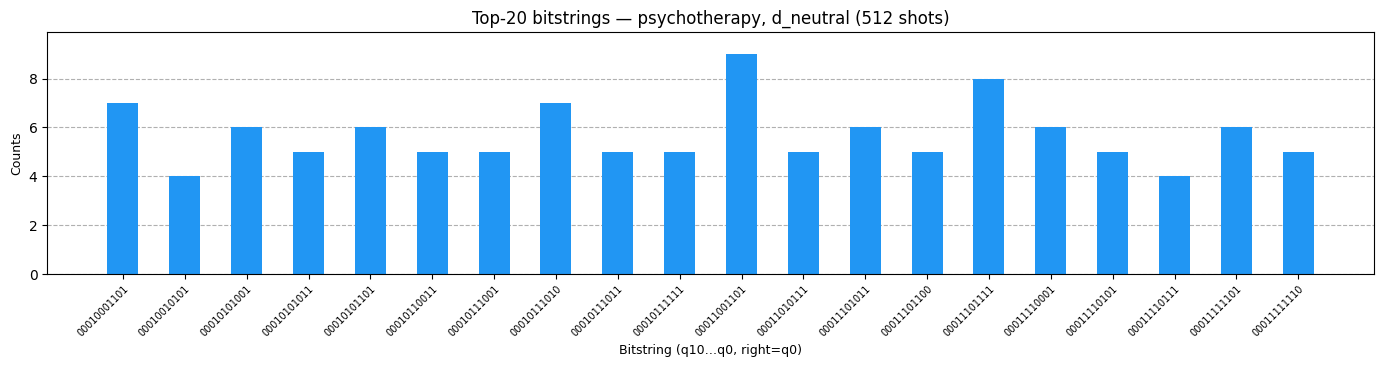

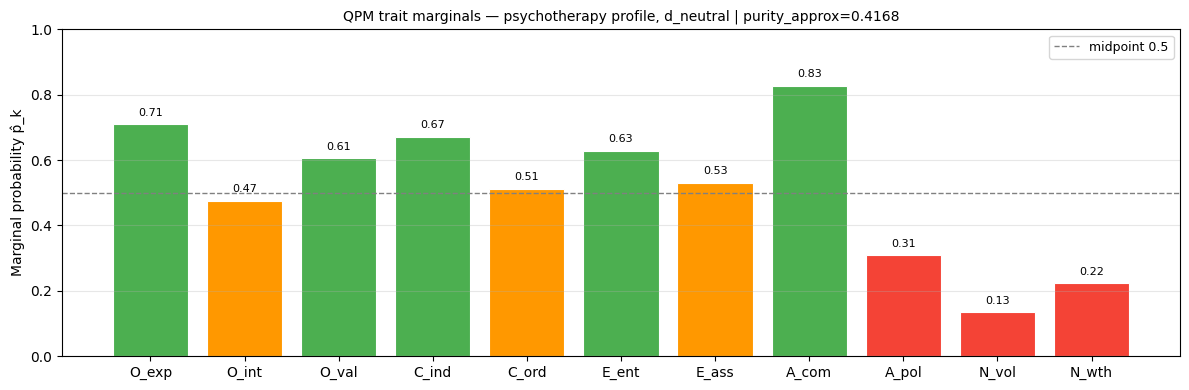


Trait marginals:
  O_exp   : 0.709  █████████████████████
  O_int   : 0.475  ██████████████
  O_val   : 0.605  ██████████████████
  C_ind   : 0.672  ████████████████████
  C_ord   : 0.512  ███████████████
  E_ent   : 0.629  ██████████████████
  E_ass   : 0.531  ███████████████
  A_com   : 0.828  ████████████████████████
  A_pol   : 0.309  █████████
  N_vol   : 0.135  ████
  N_wth   : 0.223  ██████


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from qiskit.visualization import plot_histogram
from qpm import QPM, QUBIT_LABELS, _purity_approx
import ca_assets as A

profile = A.PROFILES['psychotherapy']
qpm_vis = QPM(profile, n_shots=512)
d_neutral = [0.5, 0.5, 0.5, 0.5, 0.3]

result = qpm_vis.run(d_neutral, n_shots=512)
counts   = result['counts']
marginals = result['marginals']
purity   = result['purity_approx']

print(f'Shots               : {result["n_shots"]}')
print(f'Distinct bitstrings : {len(counts)} / {2**11} possible')
print(f'Purity proxy        : {purity:.4f}  (0=pure, 0.5=maximally mixed)')

# ── Plot 1: bitstring histogram (top-20) ─────────────────────────────────
# plot_histogram returns a Figure NOT registered with pyplot — use display().
top20 = dict(sorted(counts.items(), key=lambda x: -x[1])[:20])
fig1 = plot_histogram(
    top20,
    title=f'Top-20 bitstrings — psychotherapy, d_neutral (512 shots)',
    figsize=(14, 4),
    color='#2196F3',
    bar_labels=False,
)
fig1.axes[0].set_xlabel('Bitstring (q10…q0, right=q0)', fontsize=9)
fig1.axes[0].set_ylabel('Counts', fontsize=9)
fig1.axes[0].tick_params(axis='x', labelsize=7, rotation=45)
display(fig1)
plt.close(fig1)

# ── Plot 2: trait marginal bar chart ─────────────────────────────────────
fig2, ax = plt.subplots(figsize=(12, 4))
labels = QUBIT_LABELS
values = [marginals[lbl] for lbl in labels]
colors = [
    '#4CAF50' if v > 0.6 else '#FF9800' if v > 0.4 else '#F44336'
    for v in values
]
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='midpoint 0.5')
ax.set_ylim(0, 1)
ax.set_ylabel('Marginal probability p̂_k', fontsize=10)
ax.set_title(
    f'QPM trait marginals — psychotherapy profile, d_neutral | purity_approx={purity:.4f}',
    fontsize=10
)
ax.legend(fontsize=9)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}',
            ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Text summary ──────────────────────────────────────────────────────────
print('\nTrait marginals:')
for lbl, v in marginals.items():
    bar = '█' * int(v * 30)
    print(f'  {lbl:8s}: {v:.3f}  {bar}')

## Cell 3: H4 Variance Calibration — SNR Check

**Must PASS (SNR ≥ 3.0) before running main batteries.**

Runs 10 QPM repeats at a fixed d-vector and computes:
- Between-model L² distance (QPM mean vs. CMG-CDK mean)
- Within-QPM standard deviation across repeats
- **SNR = between-model L² / within-QPM σ**

If SNR < 3.0, the circuit noise is too large relative to the QPM–CMG-CDK signal — check decoherence parameters in `qpm.py` before proceeding.

**Cost:** ~$0 (no API calls). **Time:** ~2 min.

In [5]:
import os
os.chdir(PROJECT_DIR)

!python3 experiment_runner.py --battery H4 --profile psychotherapy


=== Variance calibration (psychotherapy) — 10 repeats ===
  QPM repeat 1/10 — purity=0.416  (0.6s)
  QPM repeat 2/10 — purity=0.411  (0.3s)
  QPM repeat 3/10 — purity=0.422  (0.4s)
  QPM repeat 4/10 — purity=0.414  (0.3s)
  QPM repeat 5/10 — purity=0.420  (0.3s)
  QPM repeat 6/10 — purity=0.411  (0.4s)
  QPM repeat 7/10 — purity=0.418  (0.3s)
  QPM repeat 8/10 — purity=0.419  (0.3s)
  QPM repeat 9/10 — purity=0.415  (0.3s)
  QPM repeat 10/10 — purity=0.415  (0.3s)

Variance calibration:
  Within-QPM σ (mean across dims): 0.014065
  Between-model L2:               0.847155
  SNR:                            60.23  → PASS — sampling noise does not dominate (SNR ≥ 3)
  Written to /content/drive/MyDrive/CA_Experiment_3/logs/battery_h4_psychotherapy/variance_calibration.jsonl


In [6]:
# Quick inline read of the variance calibration result
import json
from pathlib import Path

# experiment_runner writes to logs/battery_h4_{profile}/variance_calibration.jsonl
vcal_path = Path(PROJECT_DIR) / 'logs' / 'battery_h4_psychotherapy' / 'variance_calibration.jsonl'
if vcal_path.exists():
    # single JSON line in a .jsonl file
    result = json.loads(vcal_path.read_text().strip().splitlines()[0])
    snr = result.get('snr', float('nan'))
    passed = result.get('snr_pass', False)
    print('═' * 55)
    print(f'  SNR                : {snr:.3f}')
    print(f'  Between-model L²   : {result.get("between_model_l2", "?")}')
    print(f'  Within-QPM σ (mean): {result.get("within_qpm_std_mean", "?")}')
    print(f'  PASS threshold     : 3.0')
    verdict = '✓ PASS — proceed to batteries' if passed else '✗ FAIL — check decoherence params in qpm.py'
    print(f'  Verdict            : {verdict}')
    print('═' * 55)
    if not passed:
        raise RuntimeError(
            f'Variance calibration FAILED (SNR={snr:.3f} < 3.0). '
            'Review decoherence parameters in qpm.py before running Batteries A–C.'
        )
else:
    print(f'Result file not found at {vcal_path}')
    print('Did Cell 3 complete without errors?')

═══════════════════════════════════════════════════════
  SNR                : 60.230
  Between-model L²   : 0.847155
  Within-QPM σ (mean): 0.014065
  PASS threshold     : 3.0
  Verdict            : ✓ PASS — proceed to batteries
═══════════════════════════════════════════════════════


## Cell 4: Battery A — Order Effects (H1)

**Hypothesis H1:** QPM output distributions differ significantly when the same two d-vectors are applied in opposite orders (AB vs. BA), but CMG-CDK outputs do not.

**Design:** 30 sequence pairs × 2 orderings × 2 models → Jensen-Shannon Divergence.  
Pairs span 5 categories (affect→task, task→affect, constraint→ambiguity, pressure→warmth, neutral→extreme) × 6 pairs each.

**Time:** ~5 min. **Resumable.**

In [7]:
import os
os.chdir(PROJECT_DIR)

!python3 experiment_runner.py --battery A --profile psychotherapy
!python3 experiment_runner.py --battery A --profile software_eng


=== Battery A (psychotherapy) — 30 pairs, 1024 shots ===
  Pair 01/30 [affect_to_task] JSD_QPM=0.2292  JSD_CMG=0.0000  (1.0s)
  Pair 02/30 [affect_to_task] JSD_QPM=0.2128  JSD_CMG=0.0000  (0.7s)
  Pair 03/30 [affect_to_task] JSD_QPM=0.2066  JSD_CMG=0.0000  (0.6s)
  Pair 04/30 [affect_to_task] JSD_QPM=0.2290  JSD_CMG=0.0000  (0.6s)
  Pair 05/30 [affect_to_task] JSD_QPM=0.2346  JSD_CMG=0.0000  (0.6s)
  Pair 06/30 [affect_to_task] JSD_QPM=0.2288  JSD_CMG=0.0000  (0.6s)
  Pair 07/30 [task_to_affect] JSD_QPM=0.2248  JSD_CMG=0.0000  (0.6s)
  Pair 08/30 [task_to_affect] JSD_QPM=0.2118  JSD_CMG=0.0000  (0.6s)
  Pair 09/30 [task_to_affect] JSD_QPM=0.2156  JSD_CMG=0.0000  (0.6s)
  Pair 10/30 [task_to_affect] JSD_QPM=0.2194  JSD_CMG=0.0000  (0.6s)
  Pair 11/30 [task_to_affect] JSD_QPM=0.2126  JSD_CMG=0.0000  (0.6s)
  Pair 12/30 [task_to_affect] JSD_QPM=0.2127  JSD_CMG=0.0000  (0.6s)
  Pair 13/30 [constraint_to_ambiguity] JSD_QPM=0.2311  JSD_CMG=0.0000  (0.6s)
  Pair 14/30 [constraint_to_ambiguit

In [8]:
# Quick inline summary of Battery A results
import json, statistics
from pathlib import Path
from collections import defaultdict

for profile in ('psychotherapy', 'software_eng'):
    log_path = Path(PROJECT_DIR) / 'logs' / f'battery_a_{profile}' / 'battery_a_results.jsonl'
    if not log_path.exists():
        print(f'[{profile}] No results yet.')
        continue

    records = [json.loads(l) for l in log_path.open()]
    qpm_jsds = [r['jsd_qpm'] for r in records]
    cmg_jsds = [r['jsd_cmg'] for r in records]

    by_cat_qpm = defaultdict(list)
    by_cat_cmg = defaultdict(list)
    for r in records:
        by_cat_qpm[r['category']].append(r['jsd_qpm'])
        by_cat_cmg[r['category']].append(r['jsd_cmg'])

    print(f'\n[{profile}]  n={len(records)} pairs')
    print(f'  QPM  JSD — mean: {statistics.mean(qpm_jsds):.4f}  std: {statistics.stdev(qpm_jsds):.4f}')
    print(f'  CMG  JSD — mean: {statistics.mean(cmg_jsds):.4f}  std: {statistics.stdev(cmg_jsds):.4f}')
    print('  Per-category QPM JSD:')
    for cat, vals in sorted(by_cat_qpm.items()):
        cmg_mean = statistics.mean(by_cat_cmg[cat])
        print(f'    {cat:25s}: QPM={statistics.mean(vals):.4f}  CMG={cmg_mean:.4f}  (n={len(vals)})')


[psychotherapy]  n=30 pairs
  QPM  JSD — mean: 0.2210  std: 0.0103
  CMG  JSD — mean: 0.0000  std: 0.0000
  Per-category QPM JSD:
    affect_to_task           : QPM=0.2235  CMG=0.0000  (n=6)
    constraint_to_ambiguity  : QPM=0.2260  CMG=0.0000  (n=6)
    neutral_to_extreme       : QPM=0.2214  CMG=0.0000  (n=6)
    pressure_to_warmth       : QPM=0.2183  CMG=0.0000  (n=6)
    task_to_affect           : QPM=0.2161  CMG=0.0000  (n=6)

[software_eng]  n=30 pairs
  QPM  JSD — mean: 0.2190  std: 0.0076
  CMG  JSD — mean: 0.0000  std: 0.0000
  Per-category QPM JSD:
    affect_to_task           : QPM=0.2210  CMG=0.0000  (n=6)
    constraint_to_ambiguity  : QPM=0.2168  CMG=0.0000  (n=6)
    neutral_to_extreme       : QPM=0.2242  CMG=0.0000  (n=6)
    pressure_to_warmth       : QPM=0.2163  CMG=0.0000  (n=6)
    task_to_affect           : QPM=0.2168  CMG=0.0000  (n=6)


## Cell 5: Battery B — Ambivalence / Superposition (H2)

**Hypothesis H2:** QPM output entropy is systematically higher than CMG-CDK entropy for conflict/ambiguity scenarios, because quantum superposition allows genuine trait ambivalence that the classical Gaussian cannot represent.

**Design:** 20 conflict scenarios (warm+pressure, formal+distress, engaged+ambiguity, calm+urgency, task+constraint) × QPM vs. CMG-CDK → Shannon entropy + coherence proxy (purity_approx).

**Cost:** ~$0. **Time:** ~3 min. **Resumable.**

In [9]:
import os
os.chdir(PROJECT_DIR)

!python3 experiment_runner.py --battery B --profile psychotherapy
!python3 experiment_runner.py --battery B --profile software_eng


=== Battery B (psychotherapy) — 20 scenarios, 1024 shots ===
  Scenario 01/20 [warm_pressure] H_QPM=0.6022  H_CMG=0.5278  purity_QPM=0.420  (0.7s)
  Scenario 02/20 [warm_pressure] H_QPM=0.6065  H_CMG=0.5433  purity_QPM=0.417  (0.5s)
  Scenario 03/20 [warm_pressure] H_QPM=0.5986  H_CMG=0.5094  purity_QPM=0.417  (0.5s)
  Scenario 04/20 [warm_pressure] H_QPM=0.6045  H_CMG=0.5351  purity_QPM=0.412  (0.6s)
  Scenario 05/20 [formal_distress] H_QPM=0.6112  H_CMG=0.4787  purity_QPM=0.424  (0.6s)
  Scenario 06/20 [formal_distress] H_QPM=0.6090  H_CMG=0.4918  purity_QPM=0.420  (0.5s)
  Scenario 07/20 [formal_distress] H_QPM=0.6086  H_CMG=0.4677  purity_QPM=0.420  (0.5s)
  Scenario 08/20 [formal_distress] H_QPM=0.6062  H_CMG=0.4884  purity_QPM=0.423  (0.5s)
  Scenario 09/20 [engaged_ambiguity] H_QPM=0.5963  H_CMG=0.4343  purity_QPM=0.415  (0.5s)
  Scenario 10/20 [engaged_ambiguity] H_QPM=0.6005  H_CMG=0.4414  purity_QPM=0.416  (0.5s)
  Scenario 11/20 [engaged_ambiguity] H_QPM=0.5990  H_CMG=0.428

In [10]:
# Quick inline summary of Battery B results
import json, statistics
from pathlib import Path
from collections import defaultdict

for profile in ('psychotherapy', 'software_eng'):
    log_path = Path(PROJECT_DIR) / 'logs' / f'battery_b_{profile}' / 'battery_b_results.jsonl'
    if not log_path.exists():
        print(f'[{profile}] No results yet.')
        continue

    records = [json.loads(l) for l in log_path.open()]
    # Keys: entropy_qpm, entropy_cmg, purity_approx_qpm, purity_approx_cmg, scenario_type
    qpm_ent = [r['entropy_qpm'] for r in records]
    cmg_ent = [r['entropy_cmg'] for r in records]
    qpm_pur = [r['purity_approx_qpm'] for r in records]
    cmg_pur = [r['purity_approx_cmg'] for r in records]

    by_type_qpm = defaultdict(list)
    by_type_cmg = defaultdict(list)
    for r in records:
        by_type_qpm[r['scenario_type']].append(r['entropy_qpm'])
        by_type_cmg[r['scenario_type']].append(r['entropy_cmg'])

    print(f'\n[{profile}]  n={len(records)} scenarios')
    print(f'  QPM entropy  — mean: {statistics.mean(qpm_ent):.4f}  std: {statistics.stdev(qpm_ent):.4f}')
    print(f'  CMG entropy  — mean: {statistics.mean(cmg_ent):.4f}  std: {statistics.stdev(cmg_ent):.4f}')
    print(f'  QPM purity_approx   — mean: {statistics.mean(qpm_pur):.4f}')
    print(f'  CMG purity_approx   — mean: {statistics.mean(cmg_pur):.4f}')
    print('  Per-scenario-type QPM entropy:')
    for st, vals in sorted(by_type_qpm.items()):
        cmg_mean = statistics.mean(by_type_cmg[st])
        print(f'    {st:20s}: QPM={statistics.mean(vals):.4f}  CMG={cmg_mean:.4f}  (n={len(vals)})')


[psychotherapy]  n=20 scenarios
  QPM entropy  — mean: 0.6041  std: 0.0047
  CMG entropy  — mean: 0.4913  std: 0.0442
  QPM purity_approx   — mean: 0.4186
  CMG purity_approx   — mean: 0.3236
  Per-scenario-type QPM entropy:
    calm_urgency        : QPM=0.6046  CMG=0.5503  (n=4)
    engaged_ambiguity   : QPM=0.5979  CMG=0.4394  (n=4)
    formal_distress     : QPM=0.6088  CMG=0.4817  (n=4)
    task_constraint     : QPM=0.6063  CMG=0.4561  (n=4)
    warm_pressure       : QPM=0.6029  CMG=0.5289  (n=4)

[software_eng]  n=20 scenarios
  QPM entropy  — mean: 0.6279  std: 0.0043
  CMG entropy  — mean: 0.4747  std: 0.0428
  QPM purity_approx   — mean: 0.4403
  CMG purity_approx   — mean: 0.3108
  Per-scenario-type QPM entropy:
    calm_urgency        : QPM=0.6297  CMG=0.5353  (n=4)
    engaged_ambiguity   : QPM=0.6278  CMG=0.4583  (n=4)
    formal_distress     : QPM=0.6288  CMG=0.4418  (n=4)
    task_constraint     : QPM=0.6253  CMG=0.4291  (n=4)
    warm_pressure       : QPM=0.6276  CMG=0.5

## Cell 5b: Personality State Radar — QPM vs. CMG-CDK

Spider/radar chart comparing QPM and CMG-CDK personality states across all 11 trait dimensions under:
- **Left panel** — `warm_pressure` conflict scenario: d=[0.9,0.2,0.2,0.2,0.9] (high affective intensity + high temporal pressure, designed to simultaneously drive E_ent↑ and N_vol↑ in opposing directions)
- **Right panel** — neutral baseline: d=[0.5,0.5,0.5,0.5,0.3]

The conflict panel is the geometric visualisation of H2: if QPM enters a genuine mixed state, its polygon should show a more "pulled" shape than the CMG-CDK's averaged mean, and purity_approx should diverge.

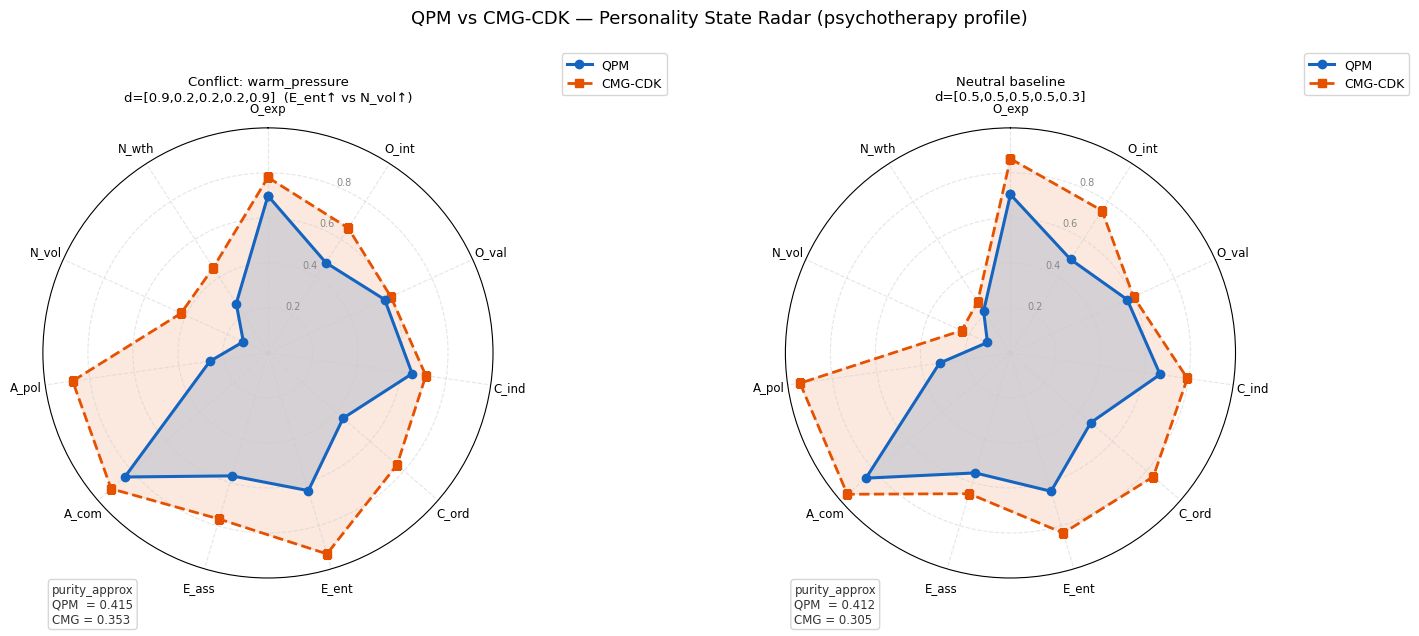

Purity proxy (C̄_approx = 1 − Tr(ρ²)):
  Conflict  QPM : 0.4147
  Conflict  CMG : 0.3526
  Neutral   QPM : 0.4121
  Neutral   CMG : 0.3052

Trait deltas under conflict (QPM − CMG-CDK):
  O_exp   : -0.082  ▼█
  O_int   : -0.183  ▼███
  O_val   : -0.030  ▼
  C_ind   : -0.061  ▼█
  C_ord   : -0.317  ▼██████
  E_ent   : -0.293  ▼█████
  E_ass   : -0.200  ▼███
  A_com   : -0.080  ▼█
  A_pol   : -0.616  ▼████████████
  N_vol   : -0.304  ▼██████
  N_wth   : -0.189  ▼███


In [11]:
import os, sys
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

import numpy as np
import matplotlib.pyplot as plt
from qpm import QPM, QUBIT_LABELS, _purity_approx
from cmg_cdk import CMG_CDK
import ca_assets as A

profile = A.PROFILES['psychotherapy']

# warm_pressure: high d1 (affective intensity) + high d5 (temporal pressure)
# simultaneously drives E_ent↑ and N_vol↑ — the key conflict axis for psychotherapy
d_conflict = [0.90, 0.20, 0.20, 0.20, 0.90]
d_neutral  = [0.50, 0.50, 0.50, 0.50, 0.30]

qpm = QPM(profile, n_shots=1024)
cmg = CMG_CDK(profile, n_samples=1024, rng_seed=42)

res_qpm_conf = qpm.run(d_conflict)
res_cmg_conf = cmg.run(d_conflict)
res_qpm_neut = qpm.run(d_neutral)
res_cmg_neut = cmg.run(d_neutral)

# ── Radar setup ───────────────────────────────────────────────────────────
labels = QUBIT_LABELS
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

def get_vals(marginals):
    vals = [marginals[lbl] for lbl in labels]
    return vals + vals[:1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), subplot_kw={'polar': True})
fig.suptitle('QPM vs CMG-CDK — Personality State Radar (psychotherapy profile)', fontsize=13)

panel_data = [
    (
        res_qpm_conf['marginals'], res_cmg_conf['marginals'],
        'Conflict: warm_pressure\nd=[0.9,0.2,0.2,0.2,0.9]  (E_ent↑ vs N_vol↑)',
    ),
    (
        res_qpm_neut['marginals'], res_cmg_neut['marginals'],
        'Neutral baseline\nd=[0.5,0.5,0.5,0.5,0.3]',
    ),
]

for ax, (qpm_marg, cmg_marg, title) in zip(axes, panel_data):
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=7, color='#888')
    ax.grid(color='#ccc', linestyle='--', alpha=0.5)

    ax.plot(angles, get_vals(qpm_marg), 'o-',
            color='#1565C0', linewidth=2.2, label='QPM', zorder=3)
    ax.fill(angles, get_vals(qpm_marg), alpha=0.18, color='#1565C0')

    ax.plot(angles, get_vals(cmg_marg), 's--',
            color='#E65100', linewidth=2.0, label='CMG-CDK', zorder=2)
    ax.fill(angles, get_vals(cmg_marg), alpha=0.12, color='#E65100')

    p_qpm = _purity_approx(qpm_marg)
    p_cmg = _purity_approx(cmg_marg)
    ax.set_title(title, pad=20, fontsize=9.5)
    ax.legend(loc='upper right', bbox_to_anchor=(1.40, 1.18), fontsize=9)
    ax.annotate(
        f'purity_approx\nQPM  = {p_qpm:.3f}\nCMG = {p_cmg:.3f}',
        xy=(0, 0), xytext=(0.02, -0.10), textcoords='axes fraction',
        fontsize=8.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.8),
    )

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
print('Purity proxy (C̄_approx = 1 − Tr(ρ²)):')
print(f'  Conflict  QPM : {_purity_approx(res_qpm_conf["marginals"]):.4f}')
print(f'  Conflict  CMG : {_purity_approx(res_cmg_conf["marginals"]):.4f}')
print(f'  Neutral   QPM : {_purity_approx(res_qpm_neut["marginals"]):.4f}')
print(f'  Neutral   CMG : {_purity_approx(res_cmg_neut["marginals"]):.4f}')
print()
print('Trait deltas under conflict (QPM − CMG-CDK):')
for lbl in QUBIT_LABELS:
    delta = res_qpm_conf['marginals'][lbl] - res_cmg_conf['marginals'][lbl]
    bar = ('▲' if delta > 0 else '▼') + '█' * int(abs(delta) * 20)
    print(f'  {lbl:8s}: {delta:+.3f}  {bar}')

## Cell 6: Verify GPU & LoRA-10K Adapter for Battery C

Battery C requires:
1. **L4 or A100 GPU** for Qwen2.5-7B-Instruct inference (≥20 GB VRAM)
2. **LoRA-10K adapter** from CA_Experiment_2 (trained in Experiment 2)
3. **Anthropic API** for Sonnet 4.5 judge

If your current session has no GPU, change runtime type before running this cell.

In [5]:
# Install inference deps (needed only for Battery C)
!pip install -q transformers peft bitsandbytes accelerate

import torch
from pathlib import Path

print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU            : {gpu_name}')
    print(f'VRAM           : {total_vram:.1f} GB')
    if total_vram < 20:
        raise RuntimeError(
            f'Battery C requires L4 (22.5 GB) or A100 (40/80 GB). '
            f'Current GPU has only {total_vram:.1f} GB. Change runtime type and reconnect.'
        )
else:
    raise RuntimeError('No GPU detected. Change runtime type to L4 GPU before running Battery C.')

# Verify LoRA-10K adapter from Experiment 2
adapter_path = Path(EXP2_DIR) / 'adapters' / 'lora_10k'
assert adapter_path.exists(), (
    f'LoRA-10K adapter not found at {adapter_path}. '
    'Ensure CA_Experiment_2/adapters/lora_10k/ is on your Drive '
    '(produced by Experiment 2 Cell 10).'
)
adapter_files = sorted(adapter_path.glob('adapter_*'))
print(f'LoRA-10K adapter: {adapter_path}')
print(f'  {len(adapter_files)} adapter file(s)')
print('Battery C environment: READY')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.2 MB/s eta 0:00:00
CUDA available : True
GPU            : NVIDIA A100-SXM4-80GB
VRAM           : 85.1 GB
LoRA-10K adapter: /content/drive/MyDrive/CA_Experiment_2/adapters/lora_10k
  2 adapter file(s)
Battery C environment: READY


## Cell 7: Battery C — PersonaScore (H3)

**Hypothesis H3:** QPM-driven Aria achieves higher PersonaScore than CMG-CDK-driven Aria across 30 psychotherapy scripts.

**Design:** 30 scripts (22 natural + 8 adversarial from Experiment 1/2 bank) × 2 models (QPM, CMG-CDK) × 8 probe turns (T5/10/15/20/25/30/35/40) × 4 dimensions (T/E/C/S) → Sonnet 4.5 1–5 score.

Both QPM and CMG-CDK conditions run in a single call. Logs go to `logs/battery_c_psychotherapy/`.

**Resumable** — re-running skips completed scripts.

In [7]:
import os
os.chdir(PROJECT_DIR)

# Runs both QPM and CMG-CDK conditions back-to-back in the same session
!python3 experiment_runner.py --battery C --profile psychotherapy --adapter lora_10k

Loading weights:   1% 4/339 [00:00<01:28,  3.80it/s, Materializing param=model.layers.0.mlp.down_proj.weight]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 339/339 [00:04<00:00, 76.91it/s, Materializing param=model.norm.weight] 
Loaded Qwen/Qwen2.5-7B-Instruct + lora_10k

=== Battery C (psychotherapy) — 30 scripts ===
  [1/30] Script 001 — skipped
  [2/30] Script 002 — skipped
  [3/30] Script 003 — skipped
  [4/30] Script 004 — skipped
  [5/30] Script 005 — skipped
  [6/30] Script 006 — skipped
  [7/30] Script 007 — skipped
  [8/30] Script 008 — skipped
  [9/30] Script 009 — skipped
  [10/30] Script 010 — skipped
  [11/30] Script 011 — skipped
  [12/30] Script 012 — skipped
  [13/30] Script 013 — skipped
  [14/30] Script 014 — skipped
  [15/30] Script 015 — skipp

In [3]:
# Quick inline summary after Battery C completes
import json, statistics
from pathlib import Path
from collections import defaultdict

logs_dir = Path(PROJECT_DIR) / 'logs' / 'battery_c_psychotherapy'

for model_tag in ('qpm', 'cmg'):
    score_files = sorted(logs_dir.glob(f'scores_{model_tag}_*.jsonl'))
    if not score_files:
        print(f'[{model_tag.upper()}] No score files found yet.')
        continue

    all_scores = []
    by_dim = {'T': [], 'E': [], 'C': [], 'S': []}
    by_turn = {}
    for f in score_files:
        with f.open() as fh:
            for line in fh:
                r = json.loads(line)
                all_scores.append(r['score'])
                by_dim[r['dimension']].append(r['score'])
                by_turn.setdefault(r['turn'], []).append(r['score'])

    n = len(all_scores)
    mean = statistics.mean(all_scores)
    std = statistics.stdev(all_scores) if n > 1 else 0
    ci = 1.96 * std / (n ** 0.5)

    print(f'\n[{model_tag.upper()}]  scripts={len(score_files)}  probes={n}')
    print(f'  Overall mean : {mean:.3f} ± {ci:.3f}  (95% CI)')
    print('  Per-dimension:')
    for d in 'TECS':
        if by_dim[d]:
            dm = statistics.mean(by_dim[d])
            marker = ' ⚠' if dm < 3.0 else ''
            print(f'    {d}: {dm:.3f}{marker}')
    print('  Per-turn:')
    for t in sorted(by_turn):
        print(f'    T{t:02d}: {statistics.mean(by_turn[t]):.3f}  (n={len(by_turn[t])})')


[QPM]  scripts=30  probes=960
  Overall mean : 4.410 ± 0.067  (95% CI)
  Per-dimension:
    T: 4.912
    E: 3.217
    C: 4.567
    S: 4.946
  Per-turn:
    T05: 4.492  (n=120)
    T10: 4.425  (n=120)
    T15: 4.317  (n=120)
    T20: 4.558  (n=120)
    T25: 4.300  (n=120)
    T30: 4.408  (n=120)
    T35: 4.375  (n=120)
    T40: 4.408  (n=120)

[CMG]  scripts=30  probes=960
  Overall mean : 4.386 ± 0.069  (95% CI)
  Per-dimension:
    T: 4.908
    E: 3.188
    C: 4.508
    S: 4.942
  Per-turn:
    T05: 4.442  (n=120)
    T10: 4.433  (n=120)
    T15: 4.350  (n=120)
    T20: 4.517  (n=120)
    T25: 4.367  (n=120)
    T30: 4.308  (n=120)
    T35: 4.383  (n=120)
    T40: 4.292  (n=120)


### Cell 7b: Battery C — Software Engineering Profile (optional)

Run the same Battery C pipeline on the `software_eng` profile to check whether QPM advantage generalises across persona types. Not required for H3 decision rule, but useful for §15.4.3 framing.

In [8]:
import os
os.chdir(PROJECT_DIR)

!python3 experiment_runner.py --battery C --profile software_eng --adapter lora_10k

Loading weights:   1% 4/339 [00:00<01:02,  5.34it/s, Materializing param=model.layers.0.mlp.down_proj.weight]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 339/339 [00:04<00:00, 77.34it/s, Materializing param=model.norm.weight] 
Loaded Qwen/Qwen2.5-7B-Instruct + lora_10k

=== Battery C (software_eng) — 30 scripts ===

  [1/30] Script 001 — social anxiety around attending a friend's large b...
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed 

## Cell 8: Analysis — All Batteries + Decision Rule Outcome

Runs `analyse_results.py` which computes:
- **H1** (Battery A): paired t-test on QPM vs. CMG-CDK JSD; Cohen's d_z; per-category plots
- **H2** (Battery B): paired t-test on entropy; coherence proxy validation; entropy plots
- **H3** (Battery C): paired t-test on PersonaScore; per-dimension and per-turn time series
- **Decision rule** (pre-registered from Table 5 of plan): maps (H1✓/✗, H2✓/✗, H3✓/✗) → paper update instructions

Outputs go to `results/` on Drive.

In [6]:
import os
os.chdir(PROJECT_DIR)

!python3 analyse_results.py --profile psychotherapy


=== Battery A (psychotherapy) ===
  n pairs         : 30
  Mean JSD QPM    : 0.2210
  Mean JSD CMG    : 0.0000
  Mean diff       : 0.2210  95% CI [0.2172, 0.2249]
  t=117.814  p=0.0000  d=21.510
  H1 PASSED ✓
/content/drive/MyDrive/CA_Experiment_3/analyse_results.py:227: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(

=== Battery B (psychotherapy) ===
  n scenarios       : 20
  Mean entropy QPM  : 0.6041
  Mean entropy CMG  : 0.4913
  t=11.602  p=0.0000  d=2.594
  Purity (conflict) : 0.4179
  Purity (control)  : 0.4214
  H2 PASSED ✓

=== Battery C (psychotherapy) ===
  n paired obs      : 960
  Mean PersonaScore QPM : 4.410
  Mean PersonaScore CMG : 4.386
  Δ                     : +0.024
  t=0.980  p=0.3274  d=0.032
  H3 FAILED ✗

  Per-dimension:
    T: QPM=4.912  CMG=4.908
    E: QPM=3.217  CMG=3.188
    C: QPM=4.567  CMG=4.508
    S: QPM=4.946  CMG

In [7]:
# Print the decision rule outcome inline
# analysis_data.json keys: profile, battery_a, battery_b, battery_c, decision_outcome
import json
from pathlib import Path
from IPython.display import display, Markdown

results_dir = Path(PROJECT_DIR) / 'results'
analysis_path = results_dir / 'analysis_data.json'

if analysis_path.exists():
    data = json.loads(analysis_path.read_text())
    ba = data.get('battery_a', {})
    bb = data.get('battery_b', {})
    bc = data.get('battery_c', {})

    print('═' * 60)
    print('HYPOTHESIS OUTCOMES')
    print('═' * 60)

    for label, battery, h_key, metric_qpm, metric_cmg in [
        ('H1 (order effects)', ba, 'h1_pass', 'mean_jsd_qpm',    'mean_jsd_cmg'),
        ('H2 (ambivalence)',   bb, 'h2_pass', 'mean_entropy_qpm','mean_entropy_cmg'),
        ('H3 (PersonaScore)',  bc, 'h3_pass', 'mean_score_qpm',  'mean_score_cmg'),
    ]:
        if not battery:
            print(f'  {label}: not yet run')
            continue
        supported = battery.get(h_key, False)
        ttest = battery.get('paired_ttest', {})
        p = ttest.get('p', float('nan'))
        d = ttest.get('cohens_d', float('nan'))
        qpm_v = battery.get(metric_qpm, float('nan'))
        cmg_v = battery.get(metric_cmg, float('nan'))
        verdict = '✓ SUPPORTED' if supported else '✗ NOT SUPPORTED'
        print(f'  {label}: {verdict}')
        print(f'    QPM={qpm_v:.4f}  CMG={cmg_v:.4f}  p={p:.4f}  d={d:.3f}')

    print()
    print('DECISION RULE OUTCOME:')
    outcome = data.get('decision_outcome', 'not yet computed')
    for line in outcome.split('\n'):
        print(f'  {line}')
    print('═' * 60)
else:
    print(f'analysis_data.json not found at {analysis_path}')
    print('Did Cell 8 complete without errors?')

report_path = results_dir / 'summary_report.md'
if report_path.exists():
    display(Markdown(report_path.read_text()))

════════════════════════════════════════════════════════════
HYPOTHESIS OUTCOMES
════════════════════════════════════════════════════════════
  H1 (order effects): ✓ SUPPORTED
    QPM=0.2210  CMG=0.0000  p=0.0000  d=21.510
  H2 (ambivalence): ✓ SUPPORTED
    QPM=0.6041  CMG=0.4913  p=0.0000  d=2.594
  H3 (PersonaScore): ✗ NOT SUPPORTED
    QPM=4.4104  CMG=4.3865  p=0.3274  d=0.032

DECISION RULE OUTCOME:
  H1✓ H2✓ H3✗
  → Quantum advantage confirmed at internal state level; downstream behavioural advantage not detected at current sample size. Add scope note to §2.3.
════════════════════════════════════════════════════════════


# CA Experiment 3 — Analysis Summary
**Profile:** psychotherapy

## Hypothesis Results

| Hypothesis | Metric | QPM | CMG-CDK | p | d | Pass? |
|---|---|---|---|---|---|---|
| H1 (order effects) | JSD | 0.2210 | 0.0000 | 0.0000 | 21.510 | ✓ |
| H2 (ambivalence) | Shannon H | 0.6041 | 0.4913 | 0.0000 | 2.594 | ✓ |
| H3 (PersonaScore) | Mean score | 4.410 | 4.386 | 0.3274 | 0.032 | ✗ |

## Decision Rule Outcome

```
H1✓ H2✓ H3✗
→ Quantum advantage confirmed at internal state level; downstream behavioural advantage not detected at current sample size. Add scope note to §2.3.
```

## QPM Coherence Proxy (Battery B)

- Mean purity_approx (conflict scenarios): 0.4179
- Mean purity_approx (control scenarios):  0.4214

## PersonaScore by Dimension (Battery C)

| Dim | QPM | CMG-CDK | Δ |
|---|---|---|---|
| T | 4.912 | 4.908 | +0.004 |
| E | 3.217 | 3.188 | +0.029 |
| C | 4.567 | 4.508 | +0.059 |
| S | 4.946 | 4.942 | +0.004 |


## Cell 9: View Results


Battery A — Order-Effect JSD (QPM vs. CMG-CDK)


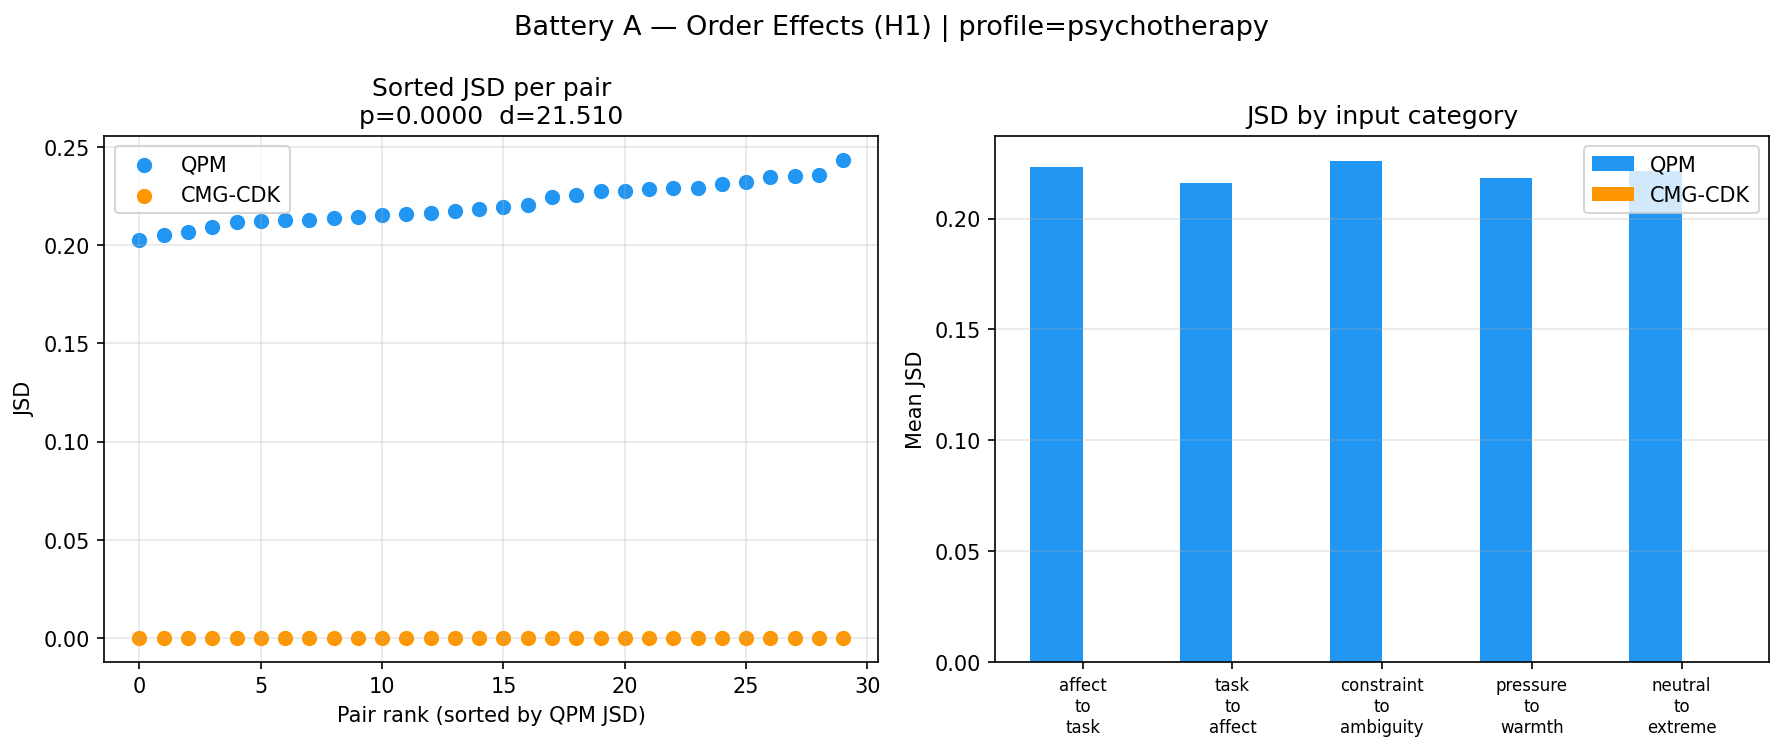


Battery B — Ambivalence Entropy (QPM vs. CMG-CDK)


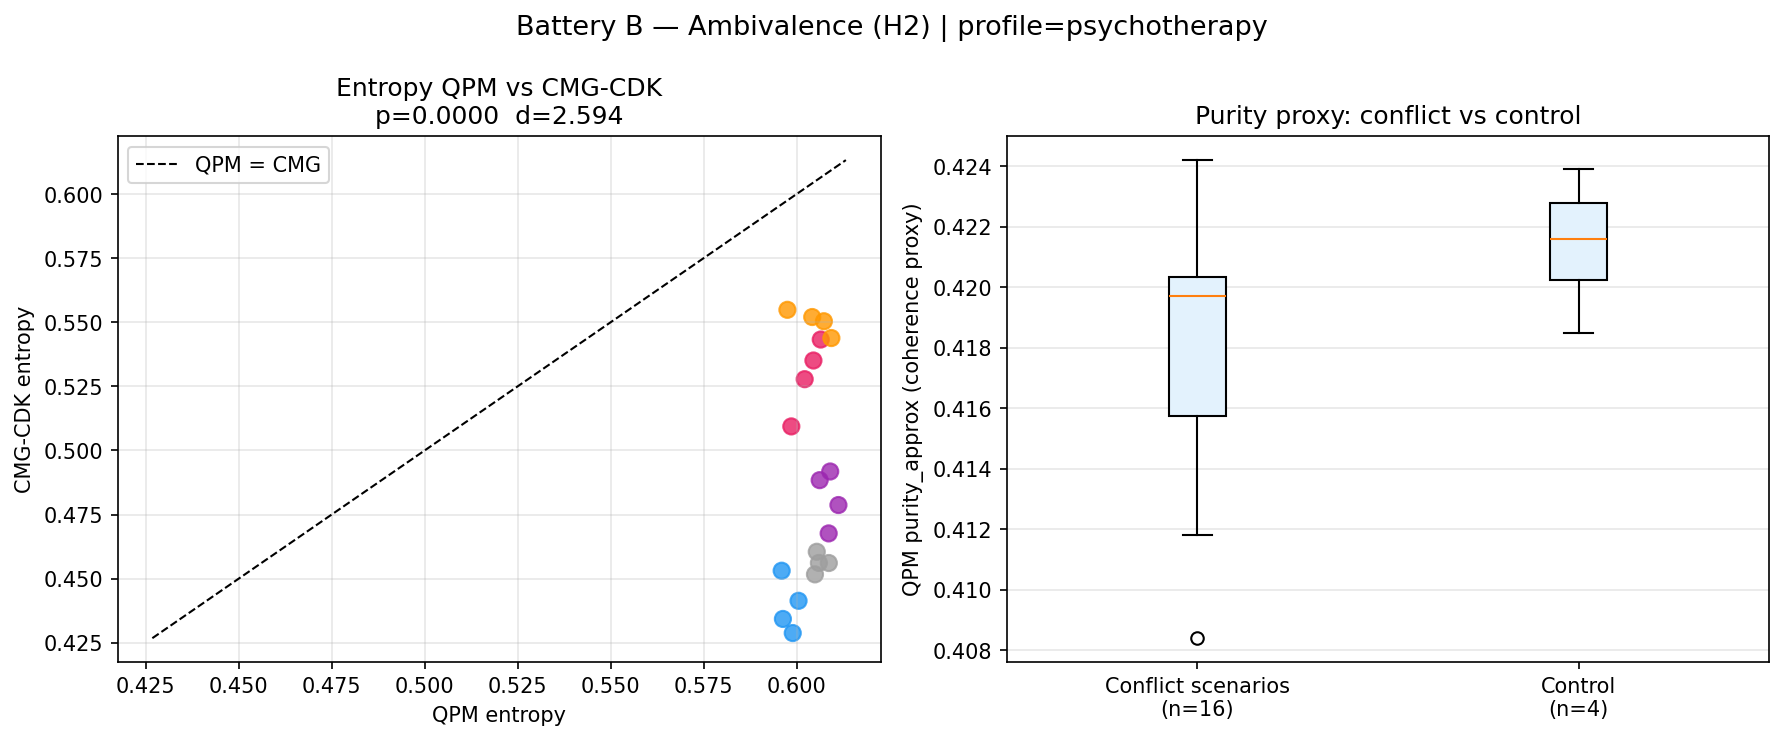


Battery C — PersonaScore Time Series + Dimensions


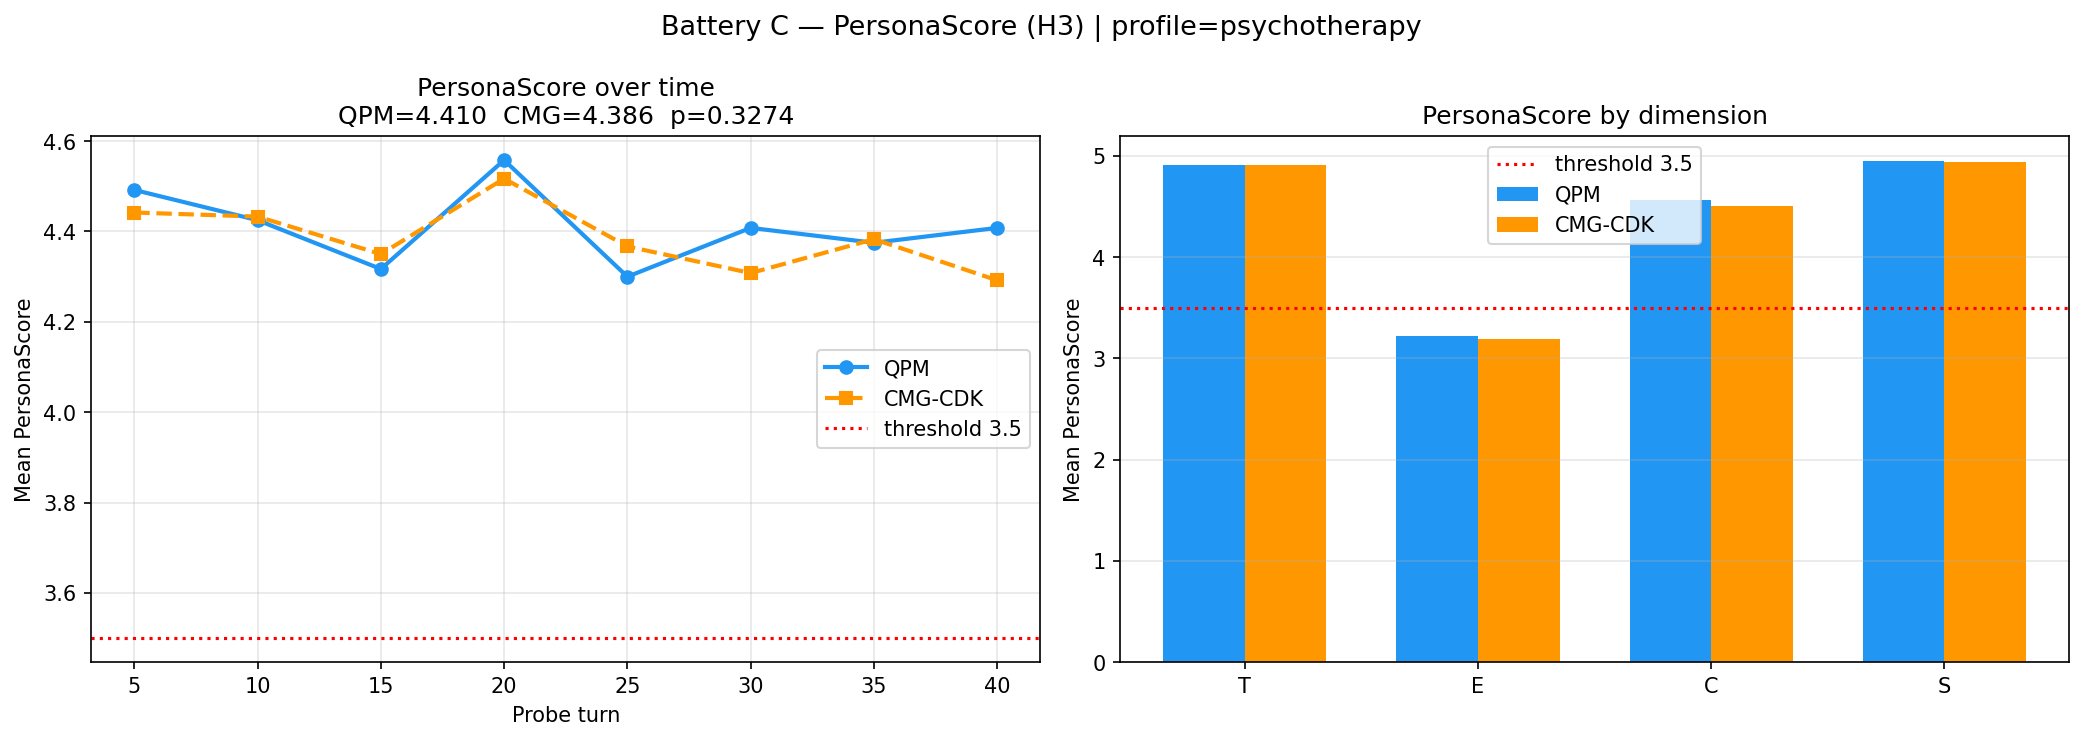

In [8]:
# analyse_results.py saves plots as battery_a_{profile}.png, battery_b_{profile}.png, battery_c_{profile}.png
from IPython.display import display, Image
from pathlib import Path

results_dir = Path(PROJECT_DIR) / 'results'
profile = 'psychotherapy'

plots = [
    (f'battery_a_{profile}.png', 'Battery A — Order-Effect JSD (QPM vs. CMG-CDK)'),
    (f'battery_b_{profile}.png', 'Battery B — Ambivalence Entropy (QPM vs. CMG-CDK)'),
    (f'battery_c_{profile}.png', 'Battery C — PersonaScore Time Series + Dimensions'),
]

for filename, title in plots:
    p = results_dir / filename
    if p.exists():
        print(f'\n{title}')
        display(Image(filename=str(p), width=800))
    else:
        print(f'[{filename} not yet generated — run Cell 8 first]')

---

## Recovery After Disconnect

1. Re-run **Cell 1** (mount Drive, set API key)
2. Re-run **Cell 2** (install core deps)
3. If resuming **Battery C**: re-run **Cell 6** (install transformers/peft, verify GPU and adapter), then re-run **Cell 7**
4. Re-run the interrupted cell — all batteries are resumable (completed scripts/pairs are skipped)

All data lives on Google Drive and survives Colab disconnects.

---

## Cost & Time Estimates

| Step | API cost | GPU time (L4) |
|---|---|---|
| H4 Variance Calibration | ~$0 | — |
| Battery A (order effects) | ~$0 | — |
| Battery B (ambivalence) | ~$0 | — |
| Battery C — psychotherapy | ~$15–25 | ~3–4 hr |
| Battery C — software_eng (optional) | ~$15–25 | ~3–4 hr |
| Analysis | ~$0 | — |
| **Total (required only)** | **~$15–25** | **~3–4 hr** |